In [47]:
import networkx as nx

In [48]:
graph = nx.read_gexf("./undirected_graph.gexf")

In [49]:
triangles = set()

for node1 in graph.nodes:
    for node2 in graph.neighbors(node1):
        for node3 in graph.neighbors(node2):
            if (graph.has_edge(node1, node3)):
                triangles.add(tuple(sorted([node1, node2, node3])))

len(triangles)

2698

In [50]:
import numpy as np

In [51]:
means = []
stdds = []
no_null = []

for node1, node2, node3 in triangles:
    w1 = graph[node1][node2]["weight"]
    w2 = graph[node1][node3]["weight"]
    w3 = graph[node3][node2]["weight"]
    weights = np.array([w1, w2, w3])
    if 0 not in weights:
        no_null.append((w1 // abs(w1), w2 // abs(w2), w3 // abs(w3)))
    stdd = weights.std()
    mean = weights.mean()
    means.append(mean)
    stdds.append(stdd)
    

In [52]:
import matplotlib.pyplot as plt

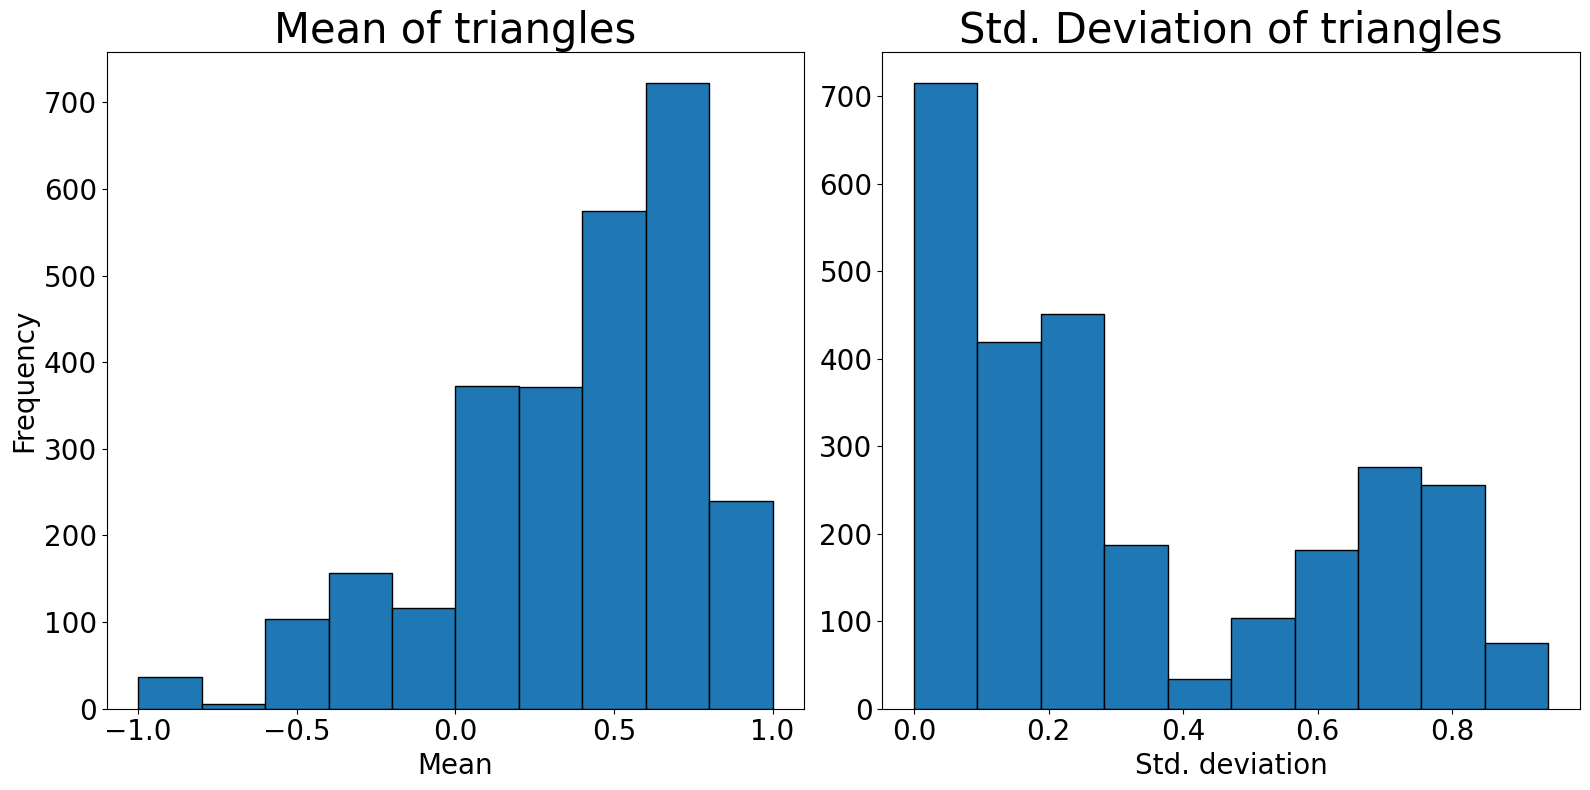

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].hist(means, bins=10, edgecolor="black")
axes[1].hist(stdds, bins=10, edgecolor="black")

axes[0].tick_params(axis="both", labelsize=20)
axes[0].set_ylabel("Frequency", fontsize=20)
axes[0].set_xlabel("Mean", fontsize=20)
axes[1].tick_params(axis="both", labelsize=20)
axes[1].set_xlabel("Std. deviation", fontsize=20)

axes[0].set_title("Mean of triangles", fontsize=30)
axes[1].set_title("Std. Deviation of triangles", fontsize=30)

plt.tight_layout()
plt.show()

In [54]:
equilibrium = 0

for triangle in no_null:
    if triangle.count(-1) % 2 == 0:
        equilibrium += 1
        
equilibrium

1978